In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv('placement.csv')

In [ ]:
df.shape
df.head()

,cgpa,package,Type
0,6.89,3.26,GOOD
1,5.12,1.98,BAD
2,7.82,3.25,GOOD
3,7.42,3.67,GOOD
4,6.94,3.57,GOOD


In [ ]:
from sklearn.preprocessing import LabelEncoder
label=LabelEncoder()
df["Type"]=label.fit_transform(df["Type"])



In [ ]:
df

,cgpa,package,Type
0,6.89,3.26,1
1,5.12,1.98,0
2,7.82,3.25,1
3,7.42,3.67,1
4,6.94,3.57,1
...,...,...,...
195,6.93,2.46,0
196,5.89,2.57,0
197,7.21,3.24,1
198,7.63,3.96,1


<Axes: xlabel='cgpa', ylabel='package'>

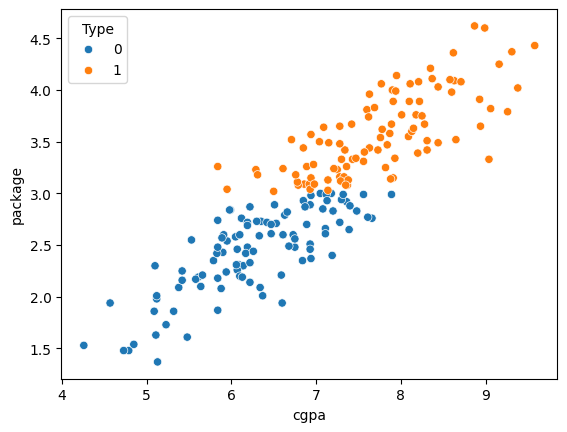

In [ ]:
sns.scatterplot(x="cgpa", y="package", hue="Type", data=df)

In [ ]:
x=df.iloc[:,:-1]
y=df.iloc[:,-1]

In [ ]:
from sklearn.linear_model import Perceptron
p= Perceptron()
p.fit(x,y)

Perceptron()

In [ ]:
p.coef_

array([[-27.04,  85.64]])

/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but Perceptron was fitted with feature names
  warnings.warn(


<Axes: >

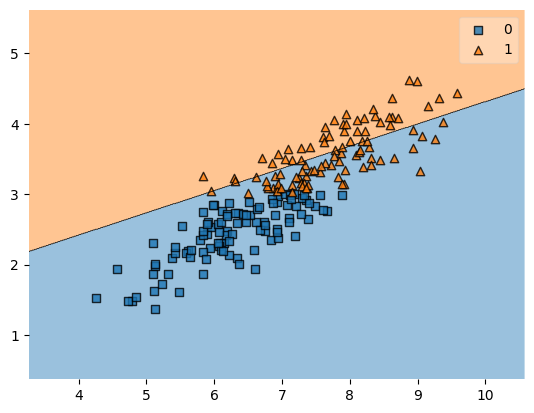

In [ ]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(x.values,y.values,clf=p)

In [ ]:
print(np.ones(x.shape[1]))

[1. 1.]


In [ ]:
def perceptron(x,y):
  x=np.insert(x,0,1,axis=1)
  weights=np.ones(x.shape[1])

  lr=1

  for i in range(100000):
    j=np.random.randint(0,200)
    y_hat=step(np.dot(x[j],weights))
    error=y[j]-y_hat
    weights=weights+lr*error*x[j]


  return weights[0],weights[1:]


1


In [ ]:
def step(z):
  return 1 if z>0 else 0

In [ ]:
intercept , coef = perceptron(x,y)

In [ ]:
m=-(coef[0]/coef[1])
c=-(intercept/coef[1])

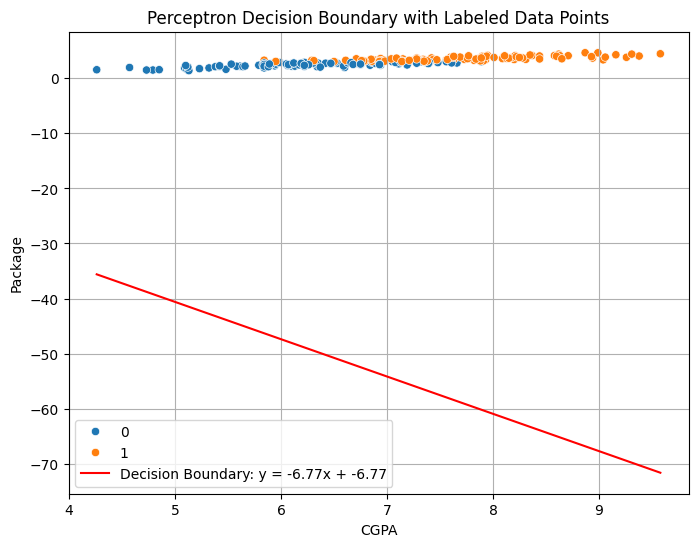

In [ ]:
x_line = np.linspace(df["cgpa"].min(), df["cgpa"].max(), 400)
y_line = m * x_line + c  # Line equation

# Plot the scatter plot of the data points
plt.figure(figsize=(8, 6))
sns.scatterplot(x="cgpa", y="package", hue="Type", data=df)

# Plot the decision boundary (line)
plt.plot(x_line, y_line, color='red', label=f'Decision Boundary: y = {m:.2f}x + {c:.2f}')

# Add labels and title
plt.xlabel('CGPA')
plt.ylabel('Package')
plt.title('Perceptron Decision Boundary with Labeled Data Points')

# Display the plot
plt.legend()
plt.grid(True)
plt.show()